# [LAB-04] 데이터 다루기

## 11. 이상치 처리

### #01 준비작업

1. 패키지 설치

In [84]:
!pip install --upgrade matplotlib

2. 라이브러리 참조

In [85]:
import numpy as np
from jussam import load_data
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

3. 데이터 가져오기

In [86]:
origin = load_data("ref_sample")
origin

📚 데이터 정제를 위한 실습용 데이터


,kor,eng,math,sic
name,,,,
철수,98.000,77,88.000,64.000
영희,88.000,120,62.000,72.000
민철,NaN,70,83.000,79.000
수현,63.000,60,31.000,71.000
호영,75.000,50,90.000,NaN
영호,80.000,88,91.000,72.000
용식,82.000,88,NaN,90.000
나영,90.000,92,81.000,NaN
석영,91.000,90,89.000,80.000


### #02 결측치 정제하기

1. 결측치를 평균으로 대체

In [87]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(origin.values)
re_df = DataFrame(df_imr, index=origin.index, columns=origin.columns)
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,120.000,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### #03 이상치가 존재하는 변수 확인

1. 상자그림 확인하기

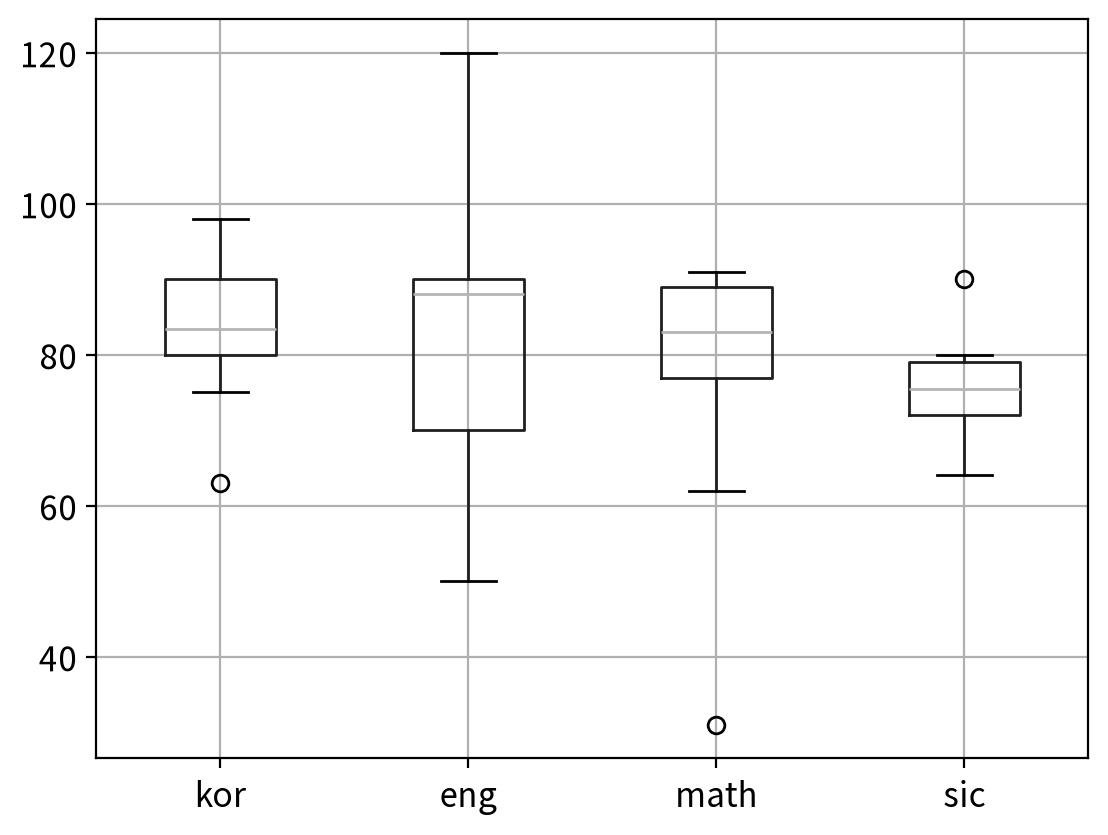

In [88]:
re_df.boxplot()
plt.show()

### #04 분석가의 주관에 의한 이상치 판별

1. 이상치를 결측치로 변경

In [89]:
re_df.loc[re_df['eng'] > 100, 'eng'] = np.nan
re_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,NaN,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


2. 변경된 결측치에 대한 처리

In [90]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(re_df.values)
outline_df = DataFrame(df_imr, index=re_df.index, columns=re_df.columns)
outline_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,63.000,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### #05 극단치 경계값을 계산하여 이상치 찾기

1. 사분위간 범위 계산

In [91]:
outline_df2 = outline_df.copy()
국어Q1 = outline_df2['kor'].quantile(0.25)
국어Q3 = outline_df2['kor'].quantile(0.75)
국어iqr = 국어Q3 - 국어Q1
print("국어 점수의 사분위간 범위:", 국어iqr)

국어 점수의 사분위간 범위: 10.0


2. 극단치 경계값 처리

In [92]:
outline_max = 국어Q3 + 국어iqr * 1.5
outline_min = 국어Q1 - 국어iqr * 1.5
print("상한 극단치 경계:", outline_max)
print("하한 극단치 경계:", outline_min)

상한 극단치 경계: 105.0
하한 극단치 경계: 65.0


3. 극단치 경계값을 활용하여 국어 점수에 대한 하한 이상치 확인

In [93]:
outline_df2.loc[outline_df2['kor'] < outline_min, 'kor']

name
수현   63.000
Name: kor, dtype: float64

4. 국어 점수에 대한 하한 이상치를 결측치로 변환

In [94]:
outline_df2.loc[outline_df2['kor'] < outline_min, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


5. 국어 점수에 대한 상한 이상치를 결측치로 변환

In [95]:
outline_df2.loc[outline_df2['kor'] > outline_max, 'kor'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,31.000,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


6. 수학 점수의 극단치 경계값을 활용한 이상치 처리

In [96]:
수학Q1 = outline_df2['math'].quantile(0.25)
수학Q3 = outline_df2['math'].quantile(0.75)
수학iqr = 수학Q3 - 수학Q1
outline_max = 수학Q3 + 수학iqr * 1.5
outline_min = 수학Q1 - 수학iqr * 1.5

outline_df2.loc[outline_df2['math'] < outline_min, 'math'] = np.nan
outline_df2.loc[outline_df2['math'] > outline_max, 'math'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,90.000
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


7. 과학 점수의 극단치 경계값을 활용한 이상치 처리

In [97]:
과학Q1 = outline_df2['sic'].quantile(0.25)
과학Q3 = outline_df2['sic'].quantile(0.75)
과학iqr = 과학Q3 - 과학Q1
outline_max = 과학Q3 + 과학iqr * 1.5
outline_min = 과학Q1 - 과학iqr * 1.5

outline_df2.loc[outline_df2['sic'] < outline_min, 'sic'] = np.nan
outline_df2.loc[outline_df2['sic'] > outline_max, 'sic'] = np.nan
outline_df2

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,NaN,60.000,NaN,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,NaN
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


8. 마지막 단계: 결측치로 변환된 값을 처리한다.

In [98]:
imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(outline_df2.values)
final_df = DataFrame(df_imr, index=outline_df2.index, columns=outline_df2.columns)
final_df

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,85.922,60.000,82.609,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,73.607
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


### #06 이상치를 이상치 경계값으로 대체하기 (모든 컬럼 일괄처리)

In [99]:
# 분석가 주관에 의한 이상치 정제 데이터에서 이어서 진행
outline_df3 = outline_df.copy()

# 컬럼만큼 반복
for c in outline_df3.columns:
    # 사분위 구간 계산
    Q1 = outline_df3[c].quantile(0.25)
    Q3 = outline_df3[c].quantile(0.75)
    iqr = Q3 - Q1

    # 이상치 경계 계산
    outline_min = Q1 - iqr * 1.5
    outline_max = Q3 + iqr * 1.5

    # 이상치 정제
    outline_df3.loc[outline_df3[c] < outline_min, c] = outline_min
    outline_df3.loc[outline_df3[c] > outline_max, c] = outline_max

outline_df3

,kor,eng,math,sic
name,,,,
철수,98.000,77.000,88.000,64.000
영희,88.000,76.875,62.000,72.000
민철,83.375,70.000,83.000,79.000
수현,65.000,60.000,58.688,71.000
호영,75.000,50.000,90.000,75.429
영호,80.000,88.000,91.000,72.000
용식,82.000,88.000,76.875,89.500
나영,90.000,92.000,81.000,75.429
석영,91.000,90.000,89.000,80.000


---

## 연습문제

### 🌱 신비한 식물 성장 기록 연구

당신은 신비한 식물의 성장 패턴을 연구하는 임무를 맡았습니다.

- 이 식물들은 각각 다른 환경에서 자라며, 이들의 성장 데이터를 수집해왔습니다.
- 수집된 데이터는 `plant_growth` 데이터 셋입니다.
- 데이터를 수집하는 센서에 가끔 오류가 발생하여 비정상적인 값이 기록될 수 있습니다.
- 데이터에서 이상치를 찾아내고 정제하여 정확한 분석을 위한 기반을 마련하세요.

### 문제 1. 데이터 불러오기 및 기본 정보 확인

`plant_growth` 데이터를 불러와 데이터프레임으로 만드세요.

데이터프레임의 기본적인 구조와 정보를 확인하세요.

- 처음 5개 행
- 각 열의 데이터 타입
- 결측치 여부

In [100]:
# 라이브러리 참조
import numpy as np
from jussam import load_data
from pandas import DataFrame
from sklearn.impute import SimpleImputer
from matplotlib import pyplot as plt

# 데이터 불러오기
plants = load_data('plant_growth')

# 처음 5개 행
plants.head()

📚 신비한 식물의 성장 기록 데이터

    field           description
--  --------------  ----------------------------------------
 0  plant_id        식물의 고유 ID(인덱스)
 1  species         식물의 종 (GlowLeaf, SunPetal, AquaRoot)
 2  height_cm       식물의 키 (cm)
 3  sunlight_hours  일일 평균 햇빛 노출 시간
 4  water_ml        일일 평균 물 공급량 (ml)



,species,height_cm,sunlight_hours,water_ml
plant_id,,,,
1,GlowLeaf,15.200,5.100,505
2,GlowLeaf,14.800,4.900,498
3,GlowLeaf,15.500,5.200,510
4,GlowLeaf,110.000,5.000,502
5,GlowLeaf,15.100,4.800,495


In [101]:
# 각 열의 데이터 타입
plants.info()

<class 'pandas.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   species         20 non-null     str    
 1   height_cm       20 non-null     float64
 2   sunlight_hours  20 non-null     float64
 3   water_ml        20 non-null     int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 960.0 bytes


In [102]:
# 결측치 여부
plants.isna().sum()

species           0
height_cm         0
sunlight_hours    0
water_ml          0
dtype: int64

### 문제 2. 데이터 시각화를 통한 이상치 탐색

각 식물 종(`species`)별로 다음 열에 대한 상자 그림(boxplot)을 그려보세요.

- `height_cm`
- `sunlight_hours`
- `water_ml`

생성된 그래프를 보고 이상치로 의심되는 값들이 어떤 열과 종에 있는지 설명해보세요.

In [122]:
# 종류 + 개수 확인
plants['species'].value_counts()       

species
GlowLeaf    7
SunPetal    7
AquaRoot    6
Name: count, dtype: int64

Species: AquaRoot


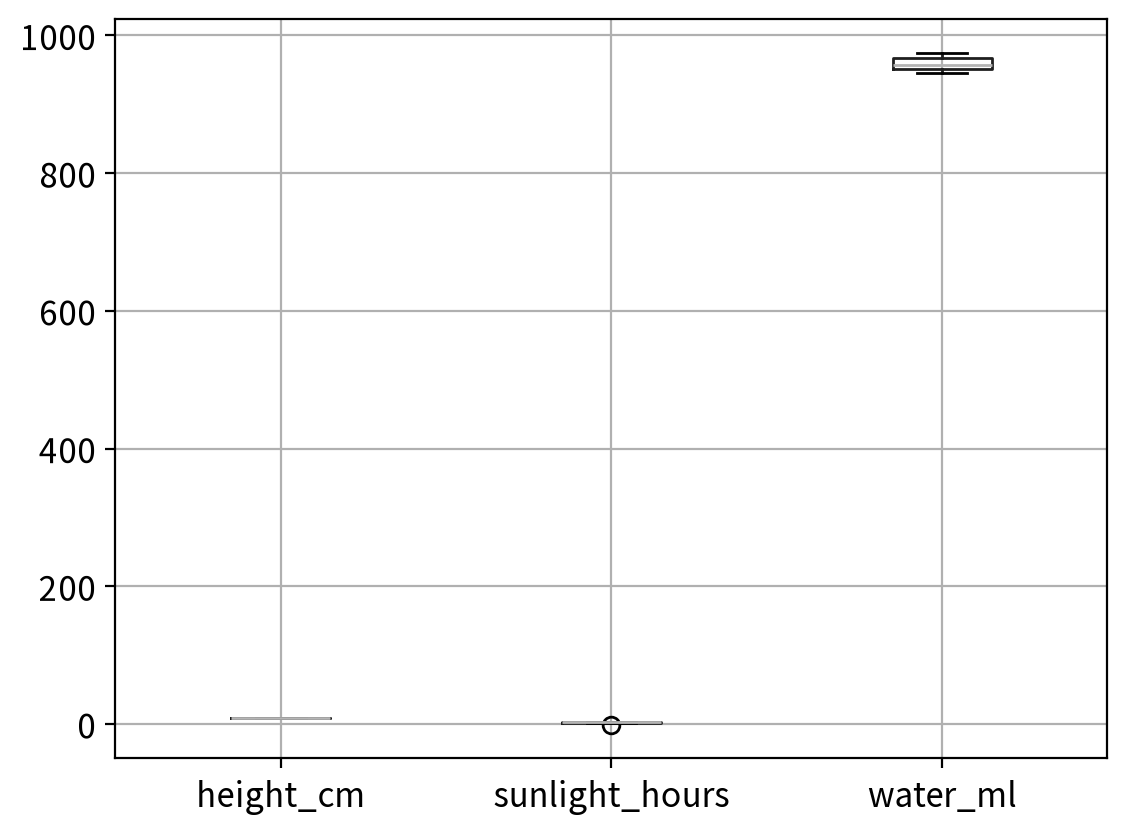

Species: GlowLeaf


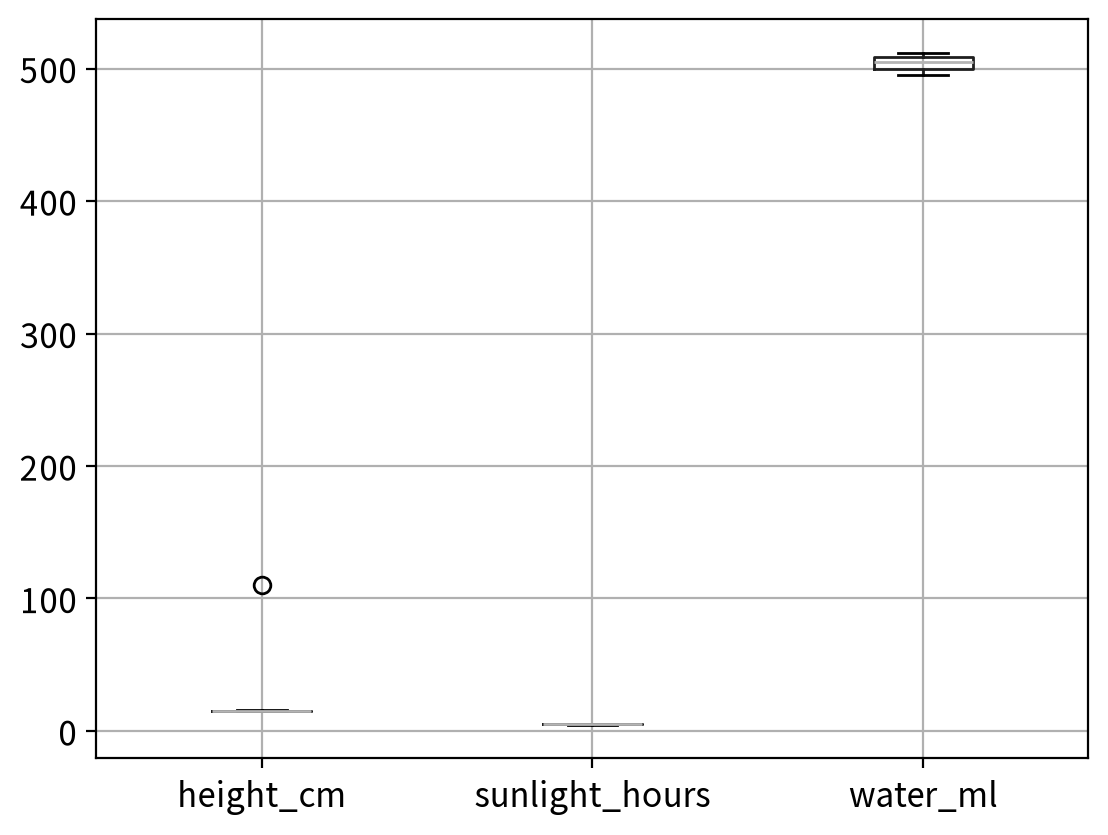

Species: SunPetal


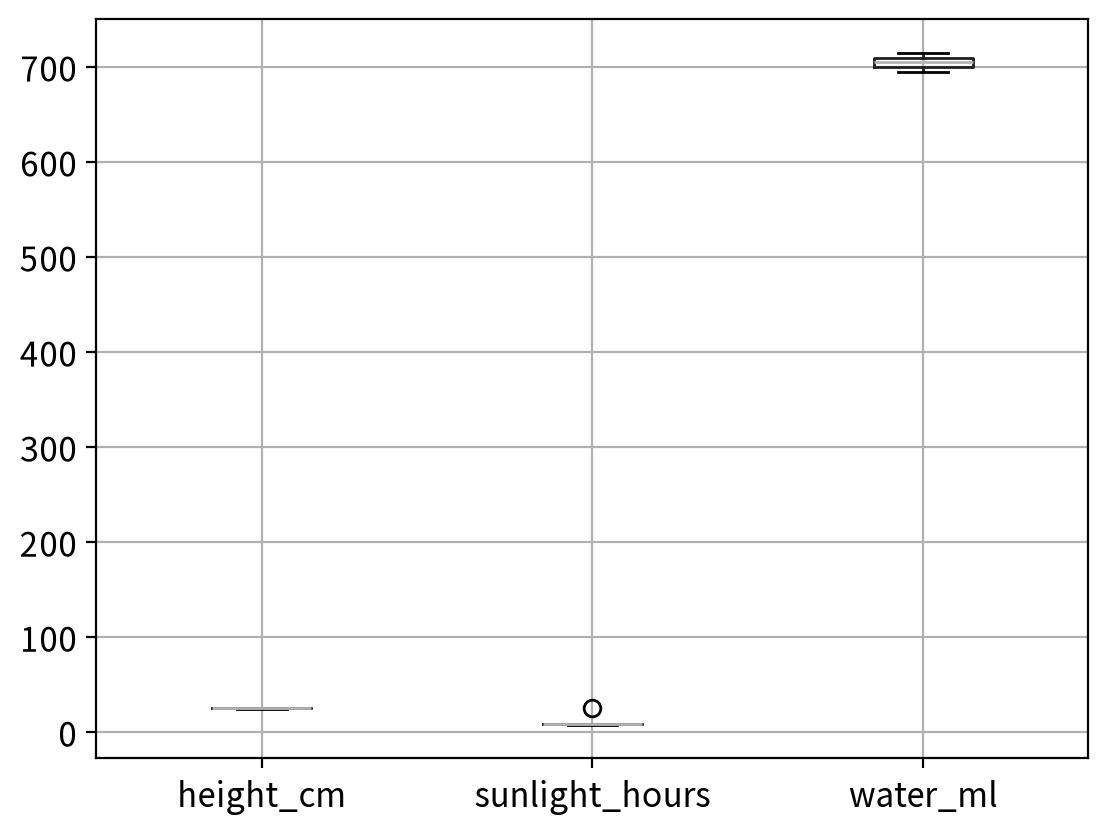

In [129]:
# 상자 그림 그리기
grouped_plants = plants.groupby('species')

for i, v in grouped_plants:
    v.boxplot()
    print(f"Species: {i}")
    plt.show()

- `GlowLeaf`종 : 키에 이상치가 검출되었다.
- `SunPetal`종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다.
- `AquaRoot`종 : 평균 햇빛 노출 시간에서 이상치가 검출되었다.

### 문제 3. IQR을 이용한 이상치 식별 및 정제

종에 대한 구별 없이 `height_cm` 열에 대해 IQR을 계산하고, 이를 바탕으로 이상치의 경계인 **하한과 상한**을 구하세요.

- 출력할 때는 소수점 둘째 자리까지만 표시하세요.
- 종에 대한 구별 없는 데이터 셋을 위해 종을 의미하는 변수를 제거하세요.
- 구한 경계를 벗어나는 이상치를 식별하고 어떤 값인지 출력하세요.

`sunlight_hours` 열에 대해서도 동일한 과정을 반복하여 이상치를 찾아내고 해당 값을 출력하세요.

마지막으로 검출된 이상치를 **평균값으로 정제**하고 결과 데이터셋을 제시하세요.

In [150]:
# height_cm에 대한 이상치 경계 구하기
outline_plants = plants.copy()

# 사분위 구간 계산
height_Q1 = outline_plants['height_cm'].quantile(0.25)
height_Q3 = outline_plants['height_cm'].quantile(0.75)
height_iqr = height_Q3 - height_Q1

# 이상치 경계 계산
height_min = height_Q1 - height_iqr * 1.5
height_max = height_Q3 + height_iqr * 1.5

print(f"height_cm에 대한 iqr: {height_iqr: .2f}, 하한 이상치 경계: {height_min: .2f}, 상한 이상치 경계: {height_max: .2f}")
outline_plants.loc[(outline_plants['height_cm'] < height_min) | (outline_plants['height_cm'] > height_max)].drop('species', axis=1)

height_cm에 대한 iqr:  16.45, 하한 이상치 경계: -16.10, 상한 이상치 경계:  49.70


,height_cm,sunlight_hours,water_ml
plant_id,,,
4,110.000,5.000,502


In [151]:
# sunlight_hours 대한 이상치 경계 구하기

# 사분위 구간 계산
sunlight_Q1 = outline_plants['sunlight_hours'].quantile(0.25)
sunlight_Q3 = outline_plants['sunlight_hours'].quantile(0.75)
sunlight_iqr = sunlight_Q3 - sunlight_Q1

# 이상치 경계 계산
sunlight_min = sunlight_Q1 - sunlight_iqr * 1.5
sunlight_max = sunlight_Q3 + sunlight_iqr * 1.5

print(f"sunlight_hours에 대한 iqr: {sunlight_iqr: .2f}, 하한 이상치 경계: {sunlight_min: .2f}, 상한 이상치 경계: {sunlight_max: .2f}")
outline_plants.loc[(outline_plants['sunlight_hours'] < sunlight_min) | (outline_plants['sunlight_hours'] > sunlight_max)].drop('species', axis=1)

sunlight_hours에 대한 iqr:  5.65, 하한 이상치 경계: -6.10, 상한 이상치 경계:  16.50


,height_cm,sunlight_hours,water_ml
plant_id,,,
10,25.400,25.000,708


In [154]:
# 이상치 대체, 데이터셋 정제
outline_plants = plants.copy().drop('species', axis=1)
outline_plants.loc[(outline_plants['height_cm'] < height_min) | (outline_plants['height_cm'] > height_max), 'height_cm'] = np.nan
outline_plants.loc[(outline_plants['sunlight_hours'] < sunlight_min) | (outline_plants['sunlight_hours'] > sunlight_max), 'sunlight_hours'] = np.nan

imr = SimpleImputer(missing_values=np.nan, strategy='mean')
df_imr = imr.fit_transform(outline_plants.values)
final_df = DataFrame(df_imr, index=outline_plants.index, columns=outline_plants.columns)
final_df

,height_cm,sunlight_hours,water_ml
plant_id,,,
1,15.200,5.100,505.000
2,14.800,4.900,498.000
3,15.500,5.200,510.000
4,16.679,5.000,502.000
5,15.100,4.800,495.000
6,25.300,8.200,705.000
7,24.900,8.100,698.000
8,25.500,8.300,710.000
9,25.100,8.000,702.000
